# **Project Title : Sleep Disorder Classification Using Optimized Ensemble Machine Learning and Genetic Algorithms**

# **1. Importing Dependencies & Project Setup**

In [2]:
!pip install missingno
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 6.0 MB/s eta 0:00:00


In [3]:
#  Basic Libraries
import numpy as np
import pandas as pd

#  Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

#  Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

#  Machine Learning Models
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

#  Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

#  Optimization
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

#  Genetic Algorithm Tools
from deap import base, creator, tools, algorithms

#  Save/Load Model
import joblib

#  Warnings
import warnings
warnings.filterwarnings("ignore")

print("All Dependencies Imported Successfully............")

All Dependencies Imported Successfully............


# **2. Data Loading**

In [5]:
#  Load Dataset
df = pd.read_csv('/content/data.csv')


print("Dataset Shape:", df.shape)

print("Dataset Loaded Successfully........")

Dataset Shape: (374, 13)
Dataset Loaded Successfully........


# **3. Exploratory Data Analysis**

In [6]:
#  Dataset Overview
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [7]:
df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [8]:
df.tail(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
364,365,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
365,366,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
366,367,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
367,368,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
368,369,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
373,374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [9]:
#  Summary Statistics
df.describe(include='all')

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,155
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,25,NaN,NaN,2
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,Sleep Apnea
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,99,NaN,NaN,78
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,NaN,70.165775,6816.844920,NaN
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,NaN,4.135676,1617.915679,NaN
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,NaN,65.000000,3000.000000,NaN
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,5600.000000,NaN
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN


In [10]:
#  Check for Null Values
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [11]:
# 🧠 Unique Values in Each Column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Person ID: 374 unique values
Gender: 2 unique values
Age: 31 unique values
Occupation: 11 unique values
Sleep Duration: 27 unique values
Quality of Sleep: 6 unique values
Physical Activity Level: 16 unique values
Stress Level: 6 unique values
BMI Category: 4 unique values
Blood Pressure: 25 unique values
Heart Rate: 19 unique values
Daily Steps: 20 unique values
Sleep Disorder: 2 unique values


In [12]:
#  Data Types of Each Column
df.dtypes

,0
Person ID,int64
Gender,object
Age,int64
Occupation,object
Sleep Duration,float64
Quality of Sleep,int64
Physical Activity Level,int64
Stress Level,int64
BMI Category,object
Blood Pressure,object


In [13]:
#  Check Class Distribution of Target Column (sleep disorder)
print("Class Distribution:\n", df['Sleep Disorder'].value_counts())

Class Distribution:
 Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64


##  **4. Data Cleaning**

### 4.1 Handle Missing Values
- Visualize missing data
- Fill numerical with median
- Fill categorical with mode

### 4.2 Remove Duplicates
- Drop duplicate rows if any

### 4.3 Clean Column Names
- Remove whitespaces from column names

### 4.4 Verify Cleaning Results
- Check dataset shape and ensure no nulls remain


<Axes: >

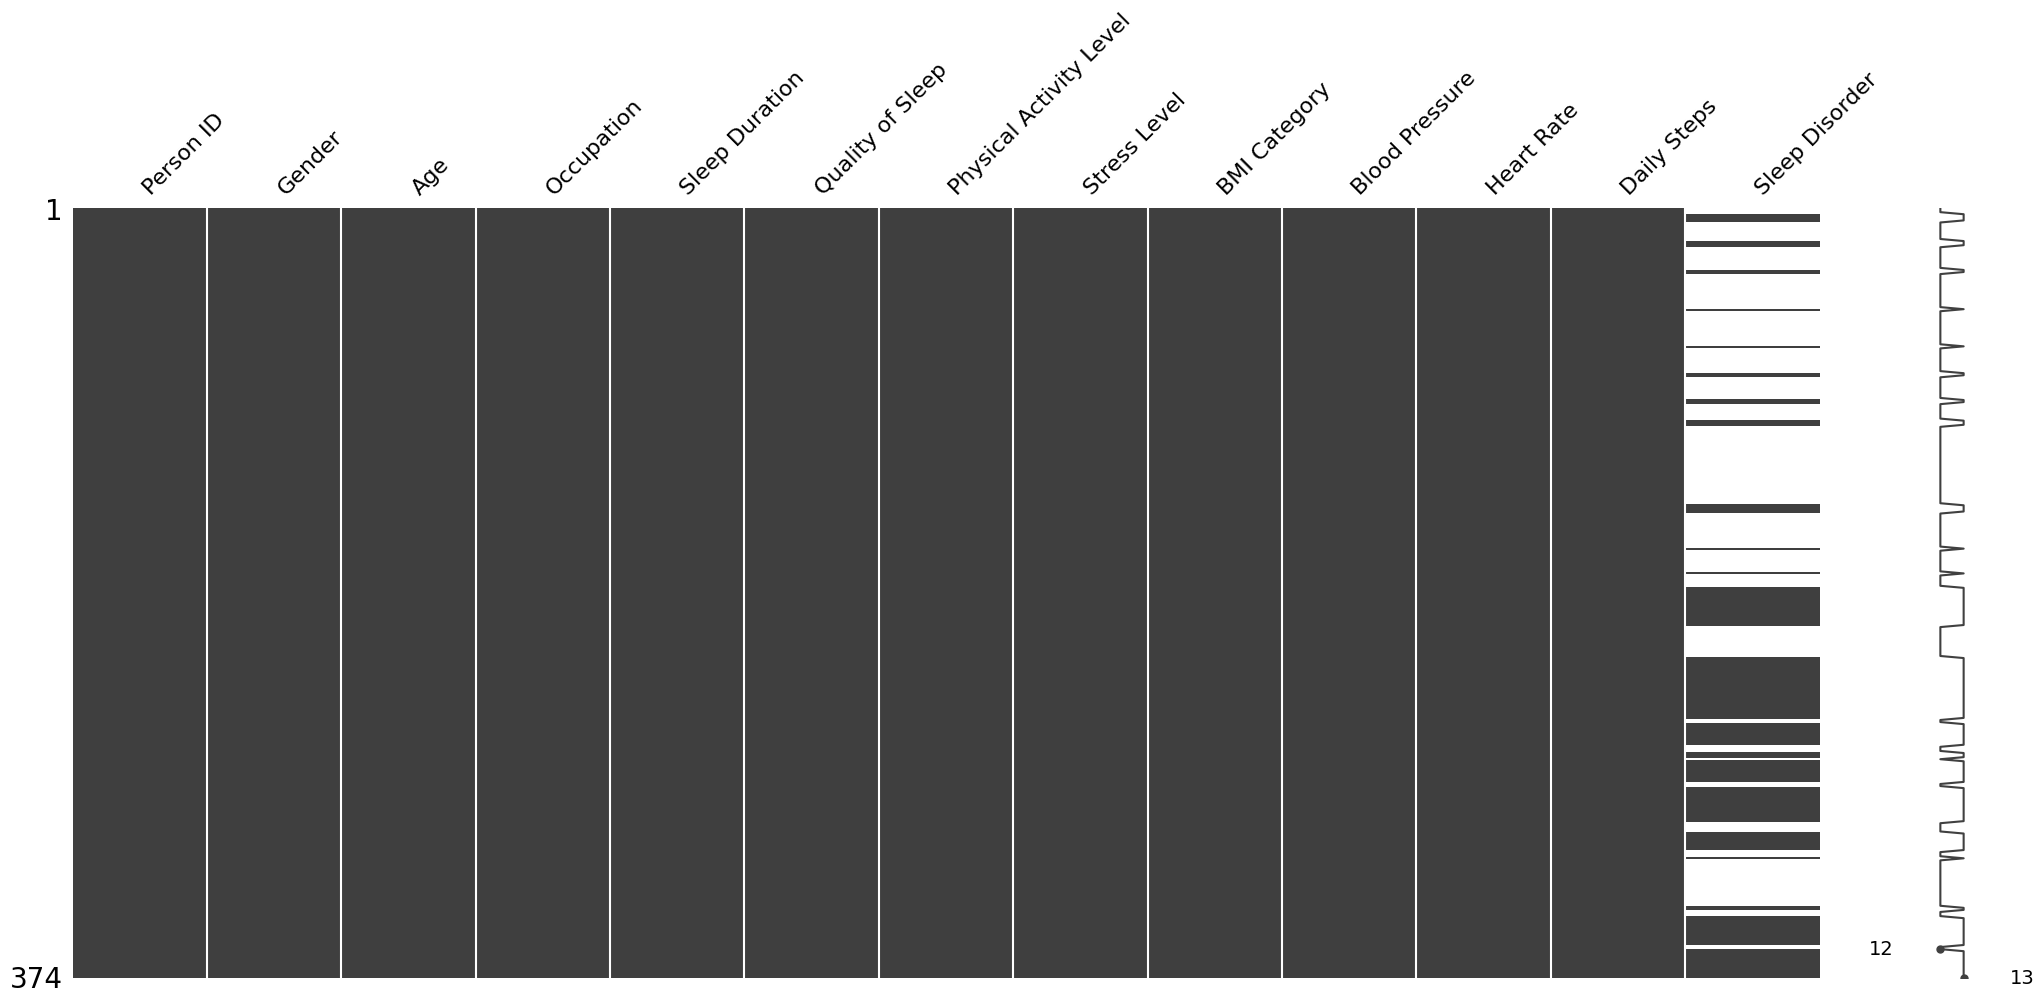

In [14]:
#  4.1 Visualize Missing Values
import missingno as msno
msno.matrix(df)

In [15]:
#  4.1 Handle Missing Values
missing_cols = df.columns[df.isnull().any()]
print("Columns with Missing Values:\n", df[missing_cols].isnull().sum())

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)


Columns with Missing Values:
 Sleep Disorder    219
dtype: int64


In [16]:
#  4.2 Remove Duplicates
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate Rows: 0


In [17]:
#  4.3 Clean Column Names
df.columns = df.columns.str.strip()

In [19]:
#  4.4 Verify Cleaning Results
print("Any Missing Values Left? ", df.isnull().sum().any())
print("Dataset Shape after Cleaning:", df.shape)

Any Missing Values Left?  False
Dataset Shape after Cleaning: (374, 13)


##  **5. Data Visualization**

### 5.1 Class Distribution
- Check the balance of the target variable (`Sleep Disorder`)

### 5.2 Numerical Feature Distributions
- Plot histograms for continuous features

### 5.3 Boxplots to Detect Outliers
- Visualize potential outliers in numerical features

### 5.4 Correlation Heatmap
- Display correlations between features

### 5.5 Pairplot for Selected Features
- Visualize interactions between features and target


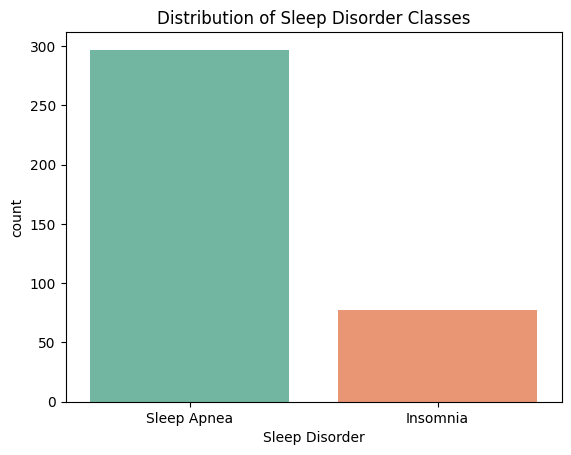

In [20]:
#  Class distribution of the target variable
sns.countplot(x='Sleep Disorder', data=df, palette='Set2')
plt.title("Distribution of Sleep Disorder Classes")
plt.show()


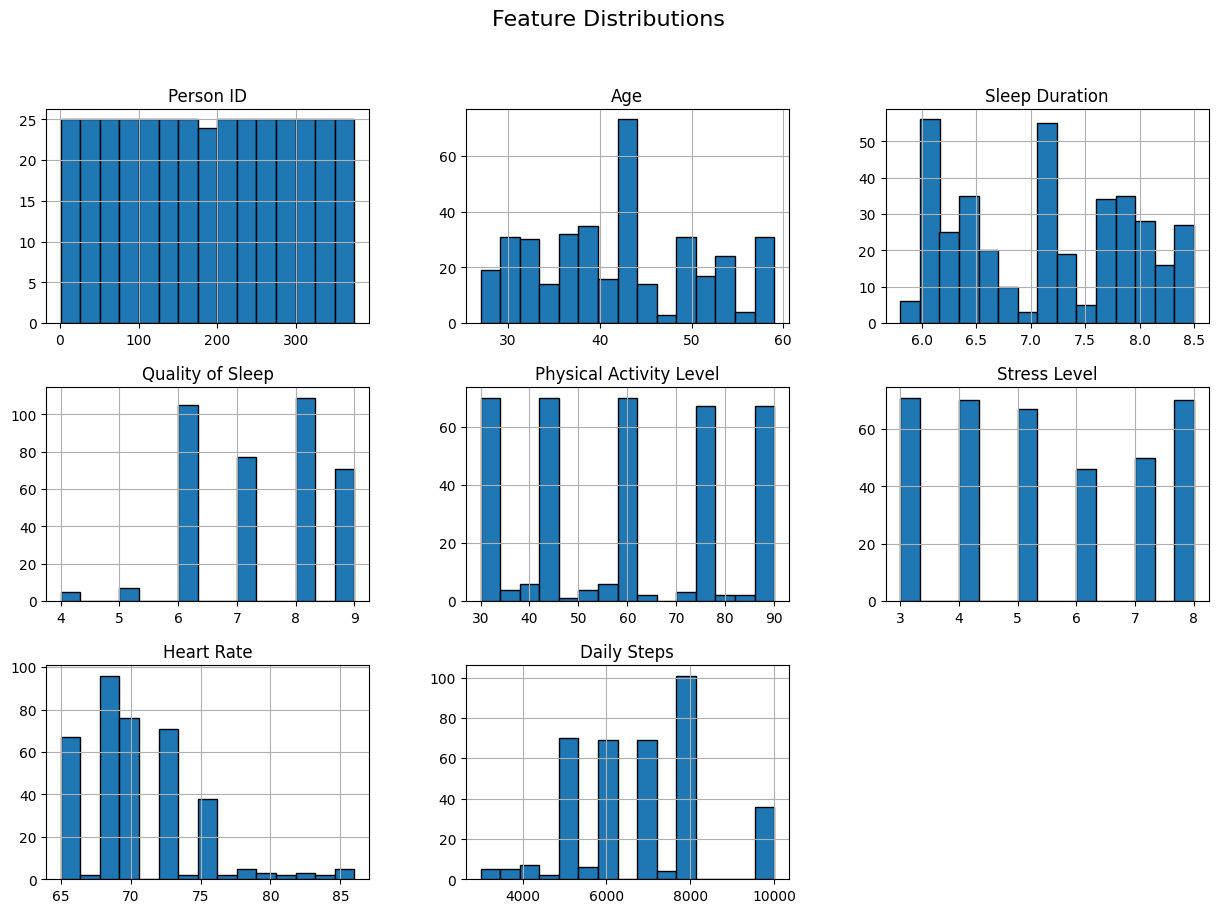

In [21]:
#  Plot histograms for numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(figsize=(15, 10), bins=15, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

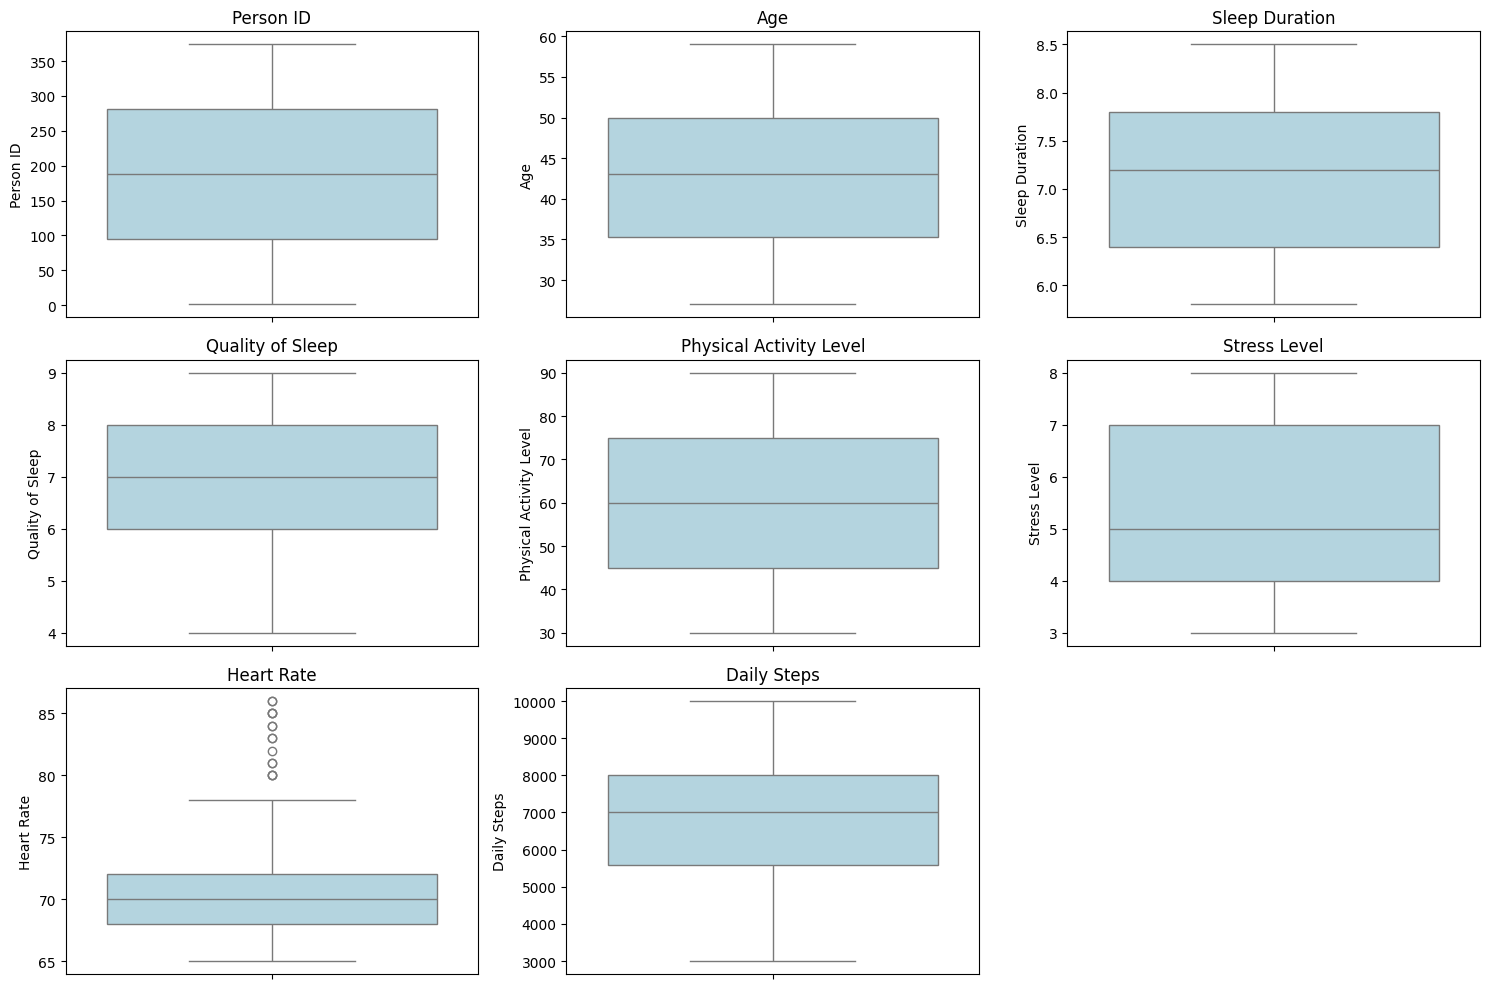

In [23]:
#  Boxplots to detect outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(col)
plt.tight_layout()
plt.show()

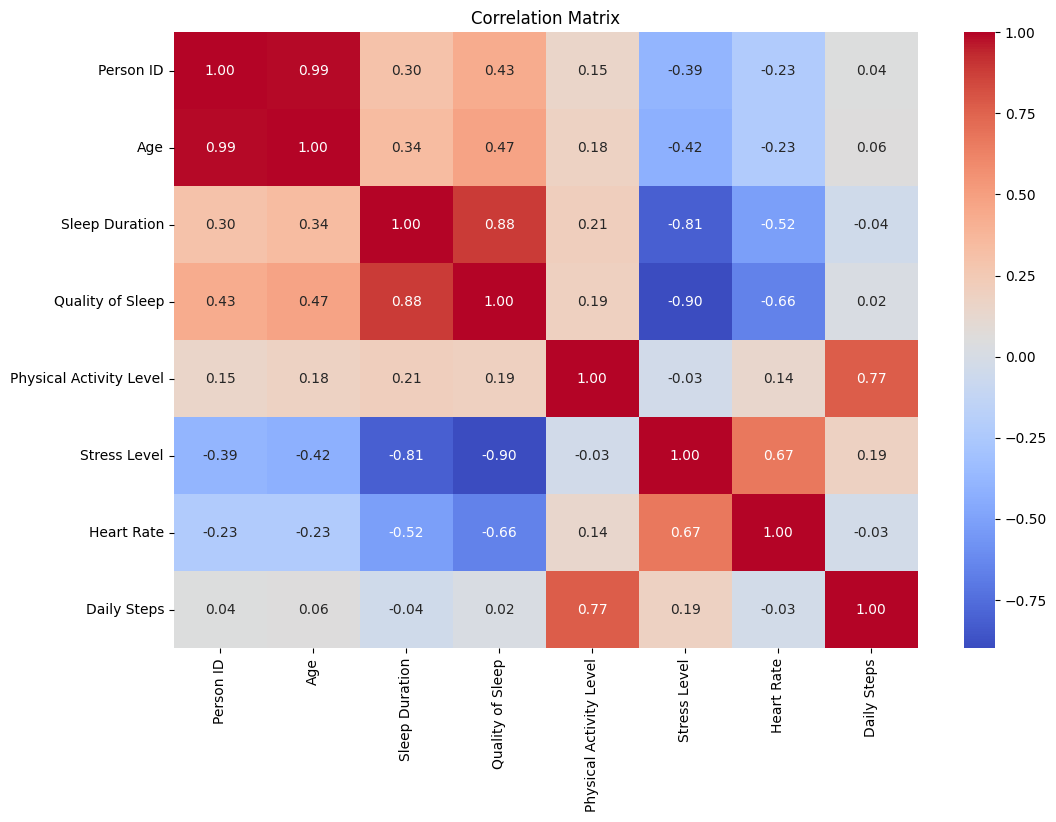

In [24]:
#  Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## **6. Feature Engineering**

### 6.1 Encode Categorical Variables
- Use Label Encoding for target and features
- Use One-Hot Encoding where applicable

### 6.2 Feature Scaling
- Apply StandardScaler to normalize numerical features

### 6.3 Optional: Feature Selection
- Use ANOVA F-value (SelectKBest) to find top features

In [26]:
#  Encode target variable: Sleep Disorder
df['Sleep Disorder'] = df['Sleep Disorder'].map({'None': 0, 'Sleep Apnea': 1, 'Insomnia': 2})

# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns
print("Categorical Columns:\n", cat_cols)

# Apply Label Encoding for categorical features
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Categorical Columns:
 Index(['Gender', 'Occupation', 'BMI Category', 'Blood Pressure'], dtype='object')


In [27]:
# Separate features and target
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

# Apply StandardScaler to features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [28]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top k features based on ANOVA F-score
selector = SelectKBest(score_func=f_classif, k='all')  # You can try k=8 or 10 to reduce dimensions
X_selected = selector.fit_transform(X_scaled, y)

# Display feature scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector.scores_
}).sort_values(by='F-Score', ascending=False)

feature_scores

,Feature,F-Score
3,Occupation,116.647247
8,BMI Category,106.969112
4,Sleep Duration,51.130445
5,Quality of Sleep,46.209596
6,Physical Activity Level,37.428632
11,Daily Steps,33.778033
9,Blood Pressure,29.166833
7,Stress Level,7.369926
0,Person ID,6.978336
2,Age,2.305292


##  **7. Advanced Data Preprocessing**

### 7.1 Class Imbalance Check
- Confirm if target classes are balanced

### 7.2 Feature Importance
- Visualize which features most influence the target

### 7.3 Multicollinearity Check
- Detect and drop highly correlated features (correlation > 0.9)

### 7.4 Final Feature Matrix and Scaling
- Prepare clean feature matrix for ML models


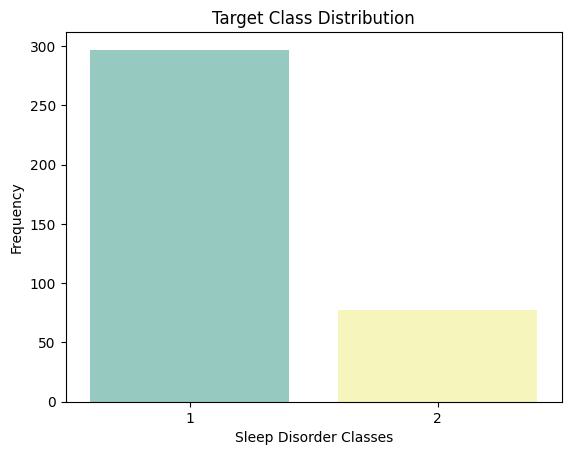

Sleep Disorder
1    297
2     77
Name: count, dtype: int64


In [30]:
#  Check target class distribution
sns.countplot(x=y, palette='Set3')
plt.title("Target Class Distribution")
plt.xlabel("Sleep Disorder Classes")
plt.ylabel("Frequency")
plt.show()

#  Count actual distribution
print(y.value_counts())

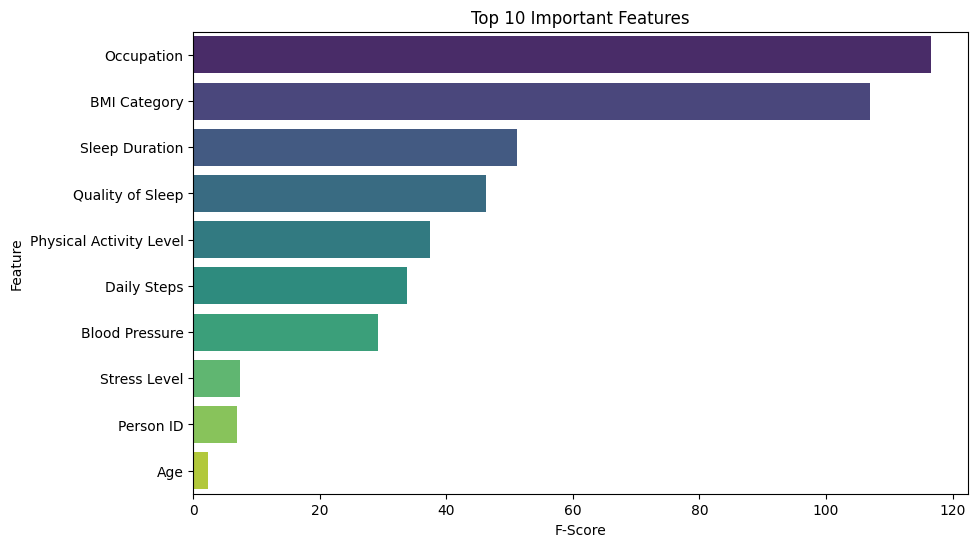

In [31]:
# Display top 10 important features again
top_features = feature_scores.sort_values(by='F-Score', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='F-Score', y='Feature', data=top_features, palette='viridis')
plt.title("Top 10 Important Features")
plt.show()

In [32]:
#  Drop highly correlated features (corr > 0.9)
corr_matrix = X_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with high correlation
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
print("Highly correlated columns to drop:", to_drop)

# Drop if necessary
X_scaled.drop(columns=to_drop, inplace=True)


Highly correlated columns to drop: ['Age']


In [33]:
# 🔄 Recompute feature selection on updated X_scaled
selector = SelectKBest(score_func=f_classif, k='all')
X_selected = selector.fit_transform(X_scaled, y)

# Final matrix dimensions
print("Final shape of input features:", X_selected.shape)

Final shape of input features: (374, 11)


## **8. Train-Test Split**

In [34]:
# 🔀 Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 📊 Check distribution after splitting
print("Training Set Class Distribution:\n", pd.Series(y_train).value_counts(normalize=True))
print("Testing Set Class Distribution:\n", pd.Series(y_test).value_counts(normalize=True))

Training Set Class Distribution:
 Sleep Disorder
1    0.793103
2    0.206897
Name: proportion, dtype: float64
Testing Set Class Distribution:
 Sleep Disorder
1    0.79646
2    0.20354
Name: proportion, dtype: float64


## **9. Model Selection**

In [35]:
# 🧠 Define all models with default settings
models = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "ANN": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
}

# 📌 Display defined models
for name, model in models.items():
    print(f"{name} model is ready.")


KNN model is ready.
SVM model is ready.
Decision Tree model is ready.
Random Forest model is ready.
ANN model is ready.


## **10. Training the Models**

In [36]:
#  Train each model
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} training completed.\n")


Training KNN...
KNN training completed.

Training SVM...
SVM training completed.

Training Decision Tree...
Decision Tree training completed.

Training Random Forest...
Random Forest training completed.

Training ANN...
ANN training completed.



##  **11. Prediction**

In [37]:
# 🔮 Make predictions with each trained model
predictions = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    print(f"{name} prediction completed.")

KNN prediction completed.
SVM prediction completed.
Decision Tree prediction completed.
Random Forest prediction completed.
ANN prediction completed.


##  **12. Evaluation**

Evaluate model predictions using the following metrics:
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

This will help identify the best baseline model before optimization.


In [39]:
#  Evaluate performance of each model
for name, y_pred in predictions.items():
    print(f"\n📌 Evaluation Report for {name}")
    print("-" * 40)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



📌 Evaluation Report for KNN
----------------------------------------
Accuracy: 0.911504424778761
Precision: 0.9085512689651071
Recall: 0.911504424778761
F1 Score: 0.9082522581945436

Classification Report:
               precision    recall  f1-score   support

           1       0.93      0.97      0.95        90
           2       0.84      0.70      0.76        23

    accuracy                           0.91       113
   macro avg       0.88      0.83      0.85       113
weighted avg       0.91      0.91      0.91       113


Confusion Matrix:
 [[87  3]
 [ 7 16]]

📌 Evaluation Report for SVM
----------------------------------------
Accuracy: 0.9292035398230089
Precision: 0.9299518479958355
Recall: 0.9292035398230089
F1 Score: 0.925035683699686

Classification Report:
               precision    recall  f1-score   support

           1       0.93      0.99      0.96        90
           2       0.94      0.70      0.80        23

    accuracy                           0.93       113

## **13. Model Performance Comparision**

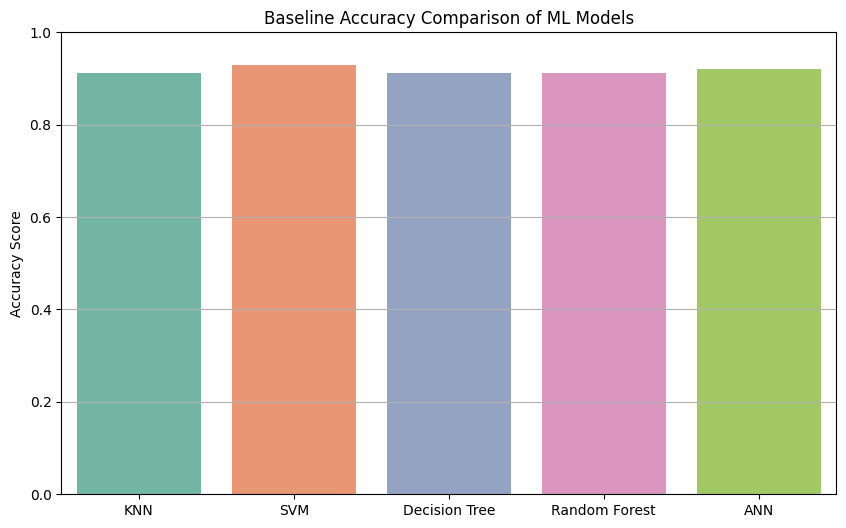

In [40]:
# 📊 Collect model accuracies
model_accuracies = {
    name: accuracy_score(y_test, predictions[name])
    for name in predictions
}

# 🎯 Plot accuracy bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette="Set2")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
plt.title("Baseline Accuracy Comparison of ML Models")
plt.grid(axis='y')
plt.show()

In [42]:
# 📊 Collect and display model accuracies
model_accuracies = {
    name: round(accuracy_score(y_test, predictions[name]) * 100, 2)
    for name in predictions
}

# Print accuracies
print("🔹 Baseline Model Accuracies (%):")
for name, acc in model_accuracies.items():
    print(f"{name:<15}: {acc}%")

# Identify best performer
best_model = max(model_accuracies, key=model_accuracies.get)
best_accuracy = model_accuracies[best_model]

print(f"\n✅ Best Performing Model: \033[1m{best_model}\033[0m with Accuracy = {best_accuracy}%")

🔹 Baseline Model Accuracies (%):
KNN            : 91.15%
SVM            : 92.92%
Decision Tree  : 91.15%
Random Forest  : 91.15%
ANN            : 92.04%

✅ Best Performing Model: SVM with Accuracy = 92.92%


## **14. Hyperparameter Tuning using Genetic Algorithm (GA)**

### 14.1 Optimizing K-Nearest Neighbors (KNN)
- Use Genetic Algorithm to find optimal value for:
  - Number of Neighbors (k)
  - Distance Metric (Euclidean, Manhattan, Minkowski)

Steps:
1. Define GA fitness function using KNN accuracy
2. Run GA to find best parameters
3. Evaluate optimized model


In [44]:
from deap import base, creator, tools, algorithms
import random
from sklearn.model_selection import cross_val_score

# 💡 Search space for KNN hyperparameters
k_range = list(range(1, 21))
distance_metrics = ['euclidean', 'manhattan', 'minkowski']

# Fitness function: maximize cross-validated accuracy
def evaluate_knn(individual):
    k = individual[0]
    metric = distance_metrics[individual[1]]

    model = KNeighborsClassifier(n_neighbors=k, metric=metric)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    return (scores.mean(),)

# 🧬 GA Setup
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("k", random.choice, k_range)
toolbox.register("metric", random.randint, 0, len(distance_metrics) - 1)
toolbox.register("individual", tools.initCycle, creator.Individual, (toolbox.k, toolbox.metric), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate_knn)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt, low=[1,0], up=[20,len(distance_metrics)-1], indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# 🔁 Run GA
pop = toolbox.population(n=20)
hof = tools.HallOfFame(1)
algorithms.eaSimple(pop, toolbox, cxpb=0.7, mutpb=0.2, ngen=10, halloffame=hof, verbose=True)

# 📌 Extract best hyperparameters
best_k = hof[0][0]
best_metric = distance_metrics[hof[0][1]]

print(f"Best KNN Parameters: k = {best_k}, metric = {best_metric}")


gen	nevals
0  	20    
1  	19    
2  	15    
3  	15    
4  	7     
5  	15    
6  	18    
7  	17    
8  	16    
9  	15    
10 	16    
Best KNN Parameters: k = 2, metric = manhattan


In [45]:
# 🧠 Train best KNN model
knn_optimized = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_optimized.fit(X_train, y_train)

# 🔮 Predict & evaluate
y_pred_knn_opt = knn_optimized.predict(X_test)

print("\n📈 Optimized KNN Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_opt))
print("Precision:", precision_score(y_test, y_pred_knn_opt, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_knn_opt, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_knn_opt, average='weighted'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn_opt))



📈 Optimized KNN Evaluation:
Accuracy: 0.911504424778761
Precision: 0.9132863764975017
Recall: 0.911504424778761
F1 Score: 0.9040719856504374

Confusion Matrix:
 [[89  1]
 [ 9 14]]


## **14.2 Hyperparameter Tuning for SVM using Genetic Algorithm**

Parameters to Optimize:
- C: [0.1, 100]
- Kernel: ['linear', 'rbf', 'poly']
- Gamma: ['scale', 'auto']
- Degree: [2, 5] (only for poly)



In [46]:
# 🧪 Search space
kernel_list = ['linear', 'rbf', 'poly']
gamma_list = ['scale', 'auto']
degree_list = [2, 3, 4, 5]

# Define fitness function for SVM
def evaluate_svm(individual):
    C = individual[0]
    kernel = kernel_list[individual[1]]
    gamma = gamma_list[individual[2]]
    degree = individual[3]

    if kernel == 'poly':
        model = SVC(C=C, kernel=kernel, gamma=gamma, degree=degree)
    else:
        model = SVC(C=C, kernel=kernel, gamma=gamma)

    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    return (score,)

# Setup GA for SVM
creator.create("FitnessMaxSVM", base.Fitness, weights=(1.0,))
creator.create("IndividualSVM", list, fitness=creator.FitnessMaxSVM)

toolbox = base.Toolbox()
toolbox.register("C", random.uniform, 0.1, 100)
toolbox.register("kernel", random.randint, 0, len(kernel_list) - 1)
toolbox.register("gamma", random.randint, 0, len(gamma_list) - 1)
toolbox.register("degree", random.choice, degree_list)

toolbox.register("individual", tools.initCycle, creator.IndividualSVM,
                 (toolbox.C, toolbox.kernel, toolbox.gamma, toolbox.degree), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate_svm)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt,
                 low=[1, 0, 0, 2], up=[100, 2, 1, 5], indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# Run GA
pop = toolbox.population(n=25)
hof = tools.HallOfFame(1)
algorithms.eaSimple(pop, toolbox, cxpb=0.7, mutpb=0.2, ngen=12, halloffame=hof, verbose= True)

# Extract best params
best_C = hof[0][0]
best_kernel = kernel_list[hof[0][1]]
best_gamma = gamma_list[hof[0][2]]
best_degree = hof[0][3]

print(f"Best SVM Parameters:\nC = {best_C:.4f}, Kernel = {best_kernel}, Gamma = {best_gamma}, Degree = {best_degree}")


gen	nevals
0  	25    
1  	19    
2  	21    
3  	22    
4  	14    
5  	22    
6  	20    
7  	20    
8  	18    
9  	20    
10 	21    
11 	19    
12 	21    
Best SVM Parameters:
C = 31.0479, Kernel = poly, Gamma = scale, Degree = 4


In [48]:
from sklearn.model_selection import GridSearchCV

# 🎯 Parameter Grid
param_grid = {
    'kernel': ['rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]  # Used only by poly kernel
}

# 🎯 Grid Search
svm_grid = GridSearchCV(SVC(probability=True), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train, y_train)

# ✅ Best model
best_svm = svm_grid.best_estimator_
print("Best SVM Parameters from Grid Search:", svm_grid.best_params_)

# 🧪 Predict & Evaluate
y_pred_svm_best = best_svm.predict(X_test)

print("\n📈 Grid-Search Optimized SVM Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_best))
print("Precision:", precision_score(y_test, y_pred_svm_best, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_svm_best, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_svm_best, average='weighted'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_best))


Best SVM Parameters from Grid Search: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}

📈 Grid-Search Optimized SVM Evaluation:
Accuracy: 0.9292035398230089
Precision: 0.9299518479958355
Recall: 0.9292035398230089
F1 Score: 0.925035683699686

Confusion Matrix:
 [[89  1]
 [ 7 16]]


## 🔹 14.3 Decision Tree (DT) Optimization using Genetic Algorithm

Parameters to Optimize:
- max_depth: [3, 15]
- min_samples_split: [2, 20]
- criterion: ['gini', 'entropy']



In [50]:
# Setup search space
criteria_list = ['gini', 'entropy']

# Define fitness function
def evaluate_dt(individual):
    max_depth = individual[0]
    min_split = individual[1]
    criterion = criteria_list[individual[2]]

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_split,
        criterion=criterion,
        random_state=42
    )
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    return (score,)

# GA Setup
creator.create("FitnessMaxDT", base.Fitness, weights=(1.0,))
creator.create("IndividualDT", list, fitness=creator.FitnessMaxDT)

toolbox = base.Toolbox()
toolbox.register("max_depth", random.randint, 3, 15)
toolbox.register("min_samples_split", random.randint, 2, 20)
toolbox.register("criterion", random.randint, 0, len(criteria_list)-1)

toolbox.register("individual", tools.initCycle, creator.IndividualDT,
                 (toolbox.max_depth, toolbox.min_samples_split, toolbox.criterion), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate_dt)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt,
                 low=[3, 2, 0], up=[15, 20, 1], indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# Run GA
pop = toolbox.population(n=20)
hof = tools.HallOfFame(1)
algorithms.eaSimple(pop, toolbox, cxpb=0.7, mutpb=0.3, ngen=10, halloffame=hof, verbose=True)

# Extract best parameters
best_depth = hof[0][0]
best_split = hof[0][1]
best_criterion = criteria_list[hof[0][2]]

print(f"✅ Best DT Parameters: max_depth = {best_depth}, min_samples_split = {best_split}, criterion = {best_criterion}")

gen	nevals
0  	20    
1  	17    
2  	20    
3  	18    
4  	13    
5  	19    
6  	12    
7  	17    
8  	18    
9  	16    
10 	12    
✅ Best DT Parameters: max_depth = 8, min_samples_split = 6, criterion = entropy


In [51]:
# Train optimized Decision Tree
dt_optimized = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_split,
    criterion=best_criterion,
    random_state=42
)
dt_optimized.fit(X_train, y_train)
y_pred_dt_opt = dt_optimized.predict(X_test)

# Evaluation
print("\n📈 Optimized Decision Tree Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_opt))
print("Precision:", precision_score(y_test, y_pred_dt_opt, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_dt_opt, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_dt_opt, average='weighted'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_opt))


📈 Optimized Decision Tree Evaluation:
Accuracy: 0.911504424778761
Precision: 0.9085512689651071
Recall: 0.911504424778761
F1 Score: 0.9082522581945436

Confusion Matrix:
 [[87  3]
 [ 7 16]]


## **12.4 Random Forest (RF) Optimization using Genetic Algorithm**


Parameters to Optimize:
- n_estimators: [50, 300]
- max_depth: [5, 30]
- min_samples_split: [2, 20]
- criterion: ['gini', 'entropy']


In [53]:
# Parameter choices
criterion_list = ['gini', 'entropy']

def evaluate_rf(individual):
    n_estimators = individual[0]
    max_depth = individual[1]
    min_samples_split = individual[2]
    criterion = criterion_list[individual[3]]

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        criterion=criterion,
        random_state=42
    )
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    return (score,)

# Setup GA types
creator.create("FitnessMaxRF", base.Fitness, weights=(1.0,))
creator.create("IndividualRF", list, fitness=creator.FitnessMaxRF)

toolbox = base.Toolbox()
toolbox.register("n_estimators", random.randint, 50, 300)
toolbox.register("max_depth", random.randint, 5, 30)
toolbox.register("min_samples_split", random.randint, 2, 20)
toolbox.register("criterion", random.randint, 0, len(criterion_list)-1)

toolbox.register("individual", tools.initCycle, creator.IndividualRF,
                 (toolbox.n_estimators, toolbox.max_depth,
                  toolbox.min_samples_split, toolbox.criterion), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate_rf)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt,
                 low=[50, 5, 2, 0],
                 up=[300, 30, 20, 1],
                 indpb=0.3)
toolbox.register("select", tools.selTournament, tournsize=3)

# Run GA
pop = toolbox.population(n=30)
hof = tools.HallOfFame(1)
algorithms.eaSimple(pop, toolbox, cxpb=0.7, mutpb=0.3, ngen=12, halloffame=hof, verbose=True)

# Best Parameters
best_n_estimators = hof[0][0]
best_max_depth = hof[0][1]
best_min_samples_split = hof[0][2]
best_criterion = criterion_list[hof[0][3]]

print(f"✅ Best RF Parameters: n_estimators = {best_n_estimators}, max_depth = {best_max_depth}, min_samples_split = {best_min_samples_split}, criterion = {best_criterion}")

gen	nevals
0  	30    
1  	23    
2  	27    
3  	25    
4  	27    
5  	25    
6  	23    
7  	26    
8  	21    
9  	27    
10 	25    
11 	28    
12 	26    
✅ Best RF Parameters: n_estimators = 54, max_depth = 30, min_samples_split = 19, criterion = entropy


In [54]:
# Train optimized RF model
rf_optimized = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    criterion=best_criterion,
    random_state=42
)
rf_optimized.fit(X_train, y_train)
y_pred_rf_opt = rf_optimized.predict(X_test)

# Evaluation
print("\n📈 Optimized Random Forest Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_opt))
print("Precision:", precision_score(y_test, y_pred_rf_opt, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf_opt, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_rf_opt, average='weighted'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_opt))



📈 Optimized Random Forest Evaluation:
Accuracy: 0.911504424778761
Precision: 0.9085512689651071
Recall: 0.911504424778761
F1 Score: 0.9082522581945436

Confusion Matrix:
 [[87  3]
 [ 7 16]]


## **14.5 ANN (MLPClassifier) Optimization using Genetic Algorithm**

Parameters to Optimize:
- hidden_layer_sizes: [(50,), (100,), (50, 50), (100, 50)]
- activation: ['relu', 'tanh']
- solver: ['adam', 'sgd']
- alpha (L2 regularization): [0.0001, 0.001, 0.01, 0.1]



In [55]:
# Define search space
layer_options = [(50,), (100,), (50, 50), (100, 50)]
activation_list = ['relu', 'tanh']
solver_list = ['adam', 'sgd']
alpha_list = [0.0001, 0.001, 0.01, 0.1]

def evaluate_ann(individual):
    hidden_layer = layer_options[individual[0]]
    activation = activation_list[individual[1]]
    solver = solver_list[individual[2]]
    alpha = alpha_list[individual[3]]

    model = MLPClassifier(hidden_layer_sizes=hidden_layer,
                          activation=activation,
                          solver=solver,
                          alpha=alpha,
                          max_iter=1000,
                          random_state=42)

    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    return (score,)

# Setup GA
creator.create("FitnessMaxANN", base.Fitness, weights=(1.0,))
creator.create("IndividualANN", list, fitness=creator.FitnessMaxANN)

toolbox = base.Toolbox()
toolbox.register("layer", random.randint, 0, len(layer_options) - 1)
toolbox.register("activation", random.randint, 0, len(activation_list) - 1)
toolbox.register("solver", random.randint, 0, len(solver_list) - 1)
toolbox.register("alpha", random.randint, 0, len(alpha_list) - 1)

toolbox.register("individual", tools.initCycle, creator.IndividualANN,
                 (toolbox.layer, toolbox.activation, toolbox.solver, toolbox.alpha), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate_ann)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt,
                 low=[0, 0, 0, 0],
                 up=[len(layer_options) - 1, len(activation_list) - 1,
                     len(solver_list) - 1, len(alpha_list) - 1],
                 indpb=0.3)
toolbox.register("select", tools.selTournament, tournsize=3)

# Run GA
pop = toolbox.population(n=30)
hof = tools.HallOfFame(1)
algorithms.eaSimple(pop, toolbox, cxpb=0.7, mutpb=0.2, ngen=15, halloffame=hof, verbose=True)

# Extract best parameters
best_layer = layer_options[hof[0][0]]
best_activation = activation_list[hof[0][1]]
best_solver = solver_list[hof[0][2]]
best_alpha = alpha_list[hof[0][3]]

print(f"✅ Best ANN Parameters:\nhidden_layer_sizes = {best_layer}, activation = {best_activation}, solver = {best_solver}, alpha = {best_alpha}")

✅ Best ANN Parameters:
hidden_layer_sizes = (50,), activation = relu, solver = adam, alpha = 0.001


In [63]:
# Train optimized ANN model
ann_optimized = MLPClassifier(
    hidden_layer_sizes=best_layer,
    activation=best_activation,
    solver=best_solver,
    alpha=best_alpha,
    max_iter=2000,
    random_state=62
)
ann_optimized.fit(X_train, y_train)
y_pred_ann_opt = ann_optimized.predict(X_test)

# Evaluation
print("\n📈 Optimized ANN Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_ann_opt))
print("Precision:", precision_score(y_test, y_pred_ann_opt, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_ann_opt, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_ann_opt, average='weighted'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ann_opt))


📈 Optimized ANN Evaluation:
Accuracy: 0.9380530973451328
Precision: 0.936825578075935
Recall: 0.9380530973451328
F1 Score: 0.936399920377599

Confusion Matrix:
 [[88  2]
 [ 5 18]]


## **15. Additional Feature Engineering**

In [65]:
df.columns.tolist()

['Person ID',
 'Gender',
 'Age',
 'Occupation',
 'Sleep Duration',
 'Quality of Sleep',
 'Physical Activity Level',
 'Stress Level',
 'BMI Category',
 'Blood Pressure',
 'Heart Rate',
 'Daily Steps',
 'Sleep Disorder']

In [68]:
df_phase2 = df.copy()  # Start from cleaned dataset

# 1. Age Group (Young <30, Mid 30–50, Old >50)
df_phase2['age_group'] = pd.cut(df_phase2['Age'],
                                bins=[0, 30, 50, 100],
                                labels=['Young', 'Middle', 'Old'])

# 2. Sleep Duration Range
df_phase2['sleep_category'] = pd.cut(df_phase2['Sleep Duration'],
                                     bins=[0, 5, 7, 10],
                                     labels=['Short', 'Normal', 'Long'])

# 3. Interaction Feature: BMI Category and Physical Activity

df_phase2['bmi_category_encoded'] = df_phase2['BMI Category']

df_phase2['bmi_activity'] = df_phase2['bmi_category_encoded'] * df_phase2['Physical Activity Level']


# Display new features
display(df_phase2[['age_group', 'sleep_category', 'bmi_activity']].head())

,age_group,sleep_category,bmi_activity
0,Young,Normal,126
1,Young,Normal,0
2,Young,Normal,0
3,Young,Normal,60
4,Young,Normal,60


In [70]:
# Label Encode new features
new_features_to_encode = ['age_group', 'sleep_category']
for col in new_features_to_encode:
    df_phase2[col] = LabelEncoder().fit_transform(df_phase2[col].astype(str))

# Display the dataframe with new encoded features
display(df_phase2[['age_group', 'sleep_category', 'bmi_activity']].head())

,age_group,sleep_category,bmi_activity
0,2,1,126
1,2,1,0
2,2,1,0
3,2,1,60
4,2,1,60


In [75]:
# Re-encode target labels to start from 0
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
y_train_phase2_encoded = le_target.fit_transform(y_train_phase2)
y_test_phase2_encoded = le_target.transform(y_test_phase2)

## **16 Implementation of XGBoost Classifier**

In [81]:
from xgboost import XGBClassifier
import xgboost as xgb

In [82]:
# Train XGBoost model with encoded labels
xgb_model = XGBClassifier(use_label_encoder=False,
                          eval_metric='mlogloss',
                          random_state=42,
                          n_estimators=150,
                          max_depth=6,
                          learning_rate=0.1)

xgb_model.fit(X_train_phase2, y_train_phase2_encoded)

# Predict
y_pred_xgb = xgb_model.predict(X_test_phase2)

# Decode predictions to original labels if needed
y_pred_xgb_decoded = le_target.inverse_transform(y_pred_xgb)

# Evaluation
print("📈 XGBoost Evaluation Metrics:")
print("Accuracy:", accuracy_score(y_test_phase2, y_pred_xgb_decoded))
print("Precision:", precision_score(y_test_phase2, y_pred_xgb_decoded, average='weighted'))
print("Recall:", recall_score(y_test_phase2, y_pred_xgb_decoded, average='weighted'))
print("F1 Score:", f1_score(y_test_phase2, y_pred_xgb_decoded, average='weighted'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_phase2, y_pred_xgb_decoded))


📈 XGBoost Evaluation Metrics:
Accuracy: 0.9203539823008849
Precision: 0.9186979247528851
Recall: 0.9203539823008849
F1 Score: 0.9165738153435111

Confusion Matrix:
 [[88  2]
 [ 7 16]]


<Figure size 1000x600 with 0 Axes>

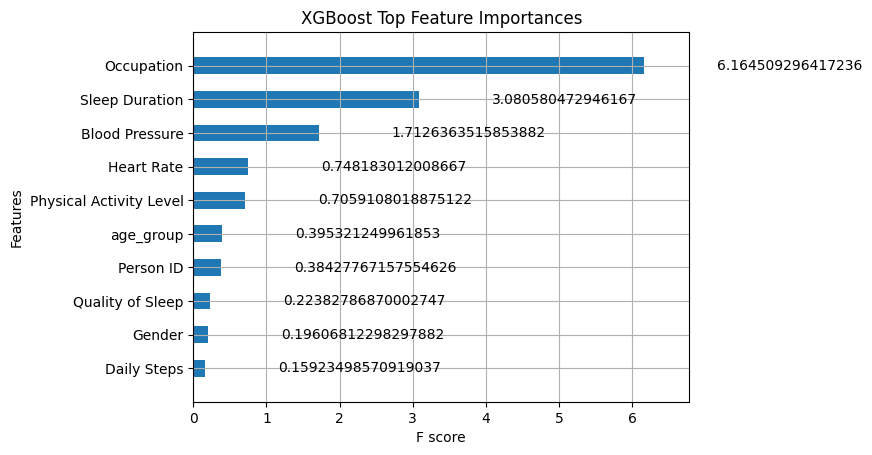

In [83]:
# Plot feature importances
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='gain', height=0.5)
plt.title("XGBoost Top Feature Importances")
plt.show()

## **17 Soft Voting Ensemble: XGBoost + ANN**

We now implement an ensemble model combining:
- Optimized XGBoost
- Optimized Artificial Neural Network (ANN)

We use **soft voting**, where the final prediction is based on the **average predicted probabilities** from both models.


In [113]:
from sklearn.ensemble import VotingClassifier

# Re-initialize the best ANN model from Phase 1
ann_model = MLPClassifier(hidden_layer_sizes=best_layer,
                          activation=best_activation,
                          solver=best_solver,
                          alpha=best_alpha,
                          max_iter=1000,
                          random_state=52)

# Important: Train ANN using encoded labels
ann_model.fit(X_train_phase2, y_train_phase2_encoded)

# Ensure XGBoost is trained with encoded labels already
# (from earlier cell: xgb_model.fit(X_train_phase2, y_train_phase2_encoded))

# Create Soft Voting Classifier
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('ann', ann_model)
    ],
    voting='soft'  # Average probabilities
)

# Fit ensemble model
ensemble_model.fit(X_train_phase2, y_train_phase2_encoded)

# Predict & decode
y_pred_ensemble = ensemble_model.predict(X_test_phase2)
y_pred_ensemble_decoded = le_target.inverse_transform(y_pred_ensemble)

# Evaluate
print("🔀 Ensemble (XGBoost + ANN) Evaluation:")
print("Precision:", precision_score(y_test_phase2, y_pred_ensemble_decoded, average='weighted'))
print("Recall:", recall_score(y_test_phase2, y_pred_ensemble_decoded, average='weighted'))
print("F1 Score:", f1_score(y_test_phase2, y_pred_ensemble_decoded, average='weighted'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_phase2, y_pred_ensemble_decoded))

🔀 Ensemble (XGBoost + ANN) Evaluation:
Precision: 0.9085512689651071
Recall: 0.911504424778761
F1 Score: 0.9082522581945436

Confusion Matrix:
 [[87  3]
 [ 7 16]]


In [89]:
import shap
shap.initjs()

In [90]:
# Use TreeExplainer (XGBoost is tree-based)
explainer = shap.Explainer(xgb_model)

# Calculate SHAP values (on a small sample for speed)
shap_values = explainer(X_test_phase2[:100])


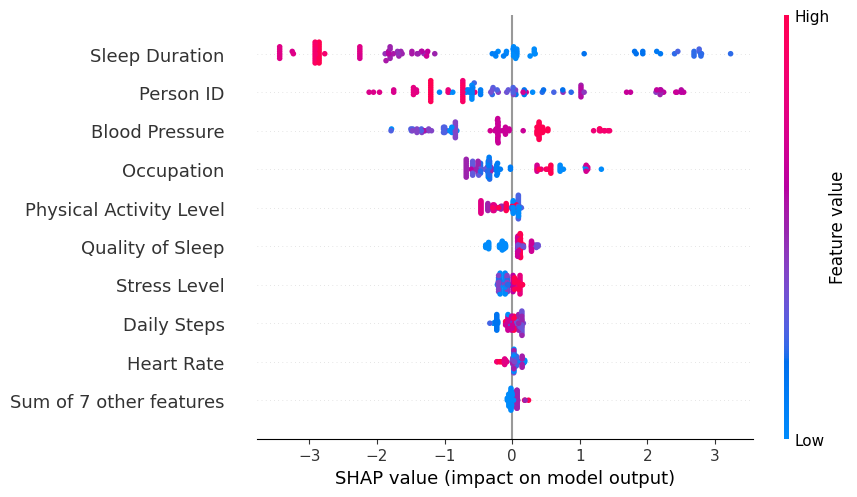

In [91]:
# SHAP Summary Plot (Feature importance + direction of impact)
shap.plots.beeswarm(shap_values)

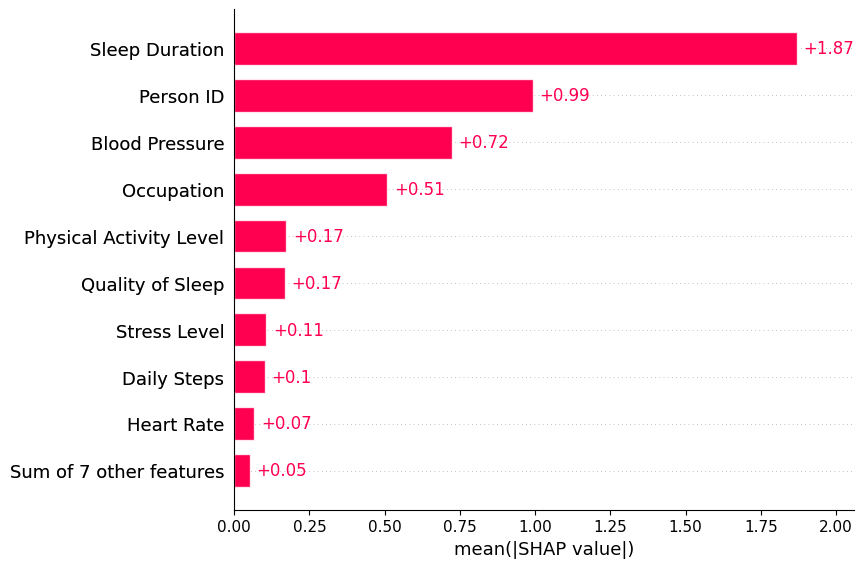

In [92]:
# SHAP Bar plot: Global feature importance
shap.plots.bar(shap_values)

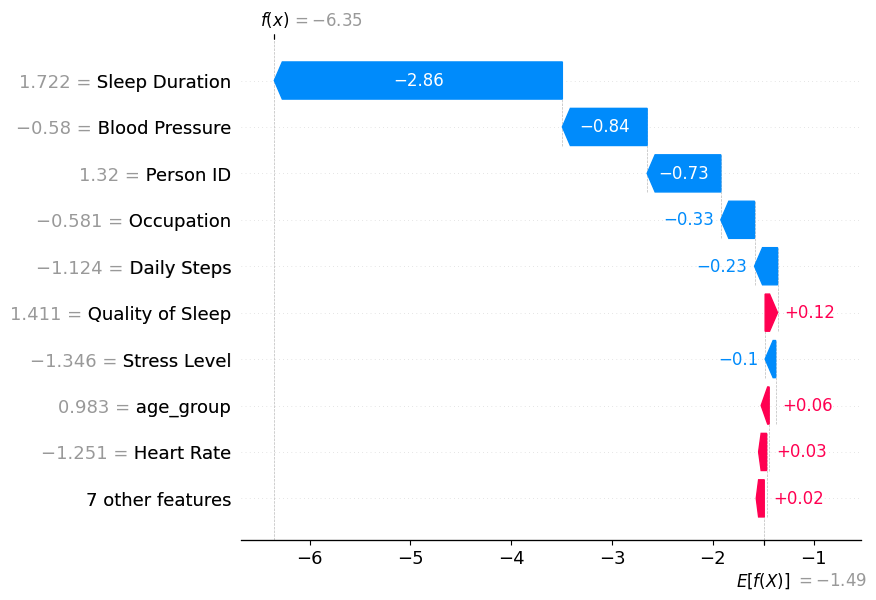

In [93]:
# Pick 5th test sample
index = 4

# Force Plot (local explanation)
shap.plots.waterfall(shap_values[index])

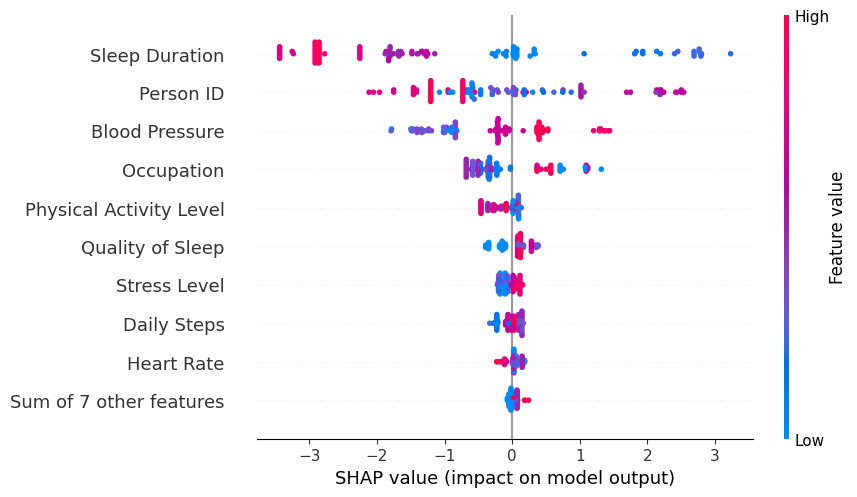

In [94]:
# Save beeswarm plot
import matplotlib.pyplot as plt
plt.figure()
shap.plots.beeswarm(shap_values, show=False)
plt.savefig("shap_summary_plot.png")
plt.show()

## **18. LightGBM Implementation**



In [95]:
import lightgbm as lgb

In [108]:
# Convert to LGBM dataset format (optional but faster)
train_set = lgb.Dataset(X_train_phase2, label=y_train_phase2_encoded)
test_set = lgb.Dataset(X_test_phase2, label=y_test_phase2_encoded, reference=train_set)

# Train LightGBM model
lgbm_model = lgb.LGBMClassifier(
    n_estimators=512,
    learning_rate=1.000,
    max_depth=20,
    num_leaves=512,
    random_state=42
)

lgbm_model.fit(X_train_phase2, y_train_phase2_encoded)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 54, number of negative: 207
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000040 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 248
[LightGBM] [Info] Number of data points in the train set: 261, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.206897 -> initscore=-1.343735
[LightGBM] [Info] Start training from score -1.343735
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMClassifier(learning_rate=1.0, max_depth=20, n_estimators=512,
               num_leaves=512, random_state=42)

In [109]:
# Predict and decode
y_pred_lgb = lgbm_model.predict(X_test_phase2)
y_pred_lgb_decoded = le_target.inverse_transform(y_pred_lgb)

# Metrics
print("📈 LightGBM Model Evaluation:")
print("Accuracy:", accuracy_score(y_test_phase2, y_pred_lgb_decoded))
print("Precision:", precision_score(y_test_phase2, y_pred_lgb_decoded, average='weighted'))
print("Recall:", recall_score(y_test_phase2, y_pred_lgb_decoded, average='weighted'))
print("F1 Score:", f1_score(y_test_phase2, y_pred_lgb_decoded, average='weighted'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_phase2, y_pred_lgb_decoded))

📈 LightGBM Model Evaluation:
Accuracy: 0.9203539823008849
Precision: 0.9186979247528851
Recall: 0.9203539823008849
F1 Score: 0.9165738153435111

Confusion Matrix:
 [[88  2]
 [ 7 16]]


## **17. Stacking Ensemble (ANN + XGB + LGBM + SVM)**

We now implement a **stacked ensemble**

### Base Learners:
- ANN (Deep Learning)
- XGBoost (Gradient Boosting)
- LightGBM (Faster boosting)
- SVM (Kernel-based learner)

### Meta Learner:
- Logistic Regression (simple, fast, interpretable)

This method captures diverse model perspectives and improves prediction robustness.


In [112]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Base models (already optimized)
base_models = [
    ('ann', MLPClassifier(hidden_layer_sizes=best_layer,
                          activation=best_activation,
                          solver=best_solver,
                          alpha=best_alpha,
                          max_iter=1000,
                          random_state=62)),

    ('xgb', XGBClassifier(use_label_encoder=False,
                          eval_metric='mlogloss',
                          random_state=62,
                          n_estimators=450,
                          max_depth=10,
                          learning_rate=0.1)),

    ('lgb', lgb.LGBMClassifier(n_estimators=250,
                               learning_rate=0.05,
                               max_depth=10,
                               num_leaves=32,
                               random_state=42)),

    ('svm', SVC(probability=True, kernel='rbf', C=1.0))
]

# Meta learner
meta_model = LogisticRegression()

# Create stacked model
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# Train
stacking_model.fit(X_train_phase2, y_train_phase2_encoded)

# Predict
y_pred_stack = stacking_model.predict(X_test_phase2)
y_pred_stack_decoded = le_target.inverse_transform(y_pred_stack)

# Evaluate
print("📊 Final Stacked Model Evaluation:")
print("Accuracy:", accuracy_score(y_test_phase2, y_pred_stack_decoded))
print("Precision:", precision_score(y_test_phase2, y_pred_stack_decoded, average='weighted'))
print("Recall:", recall_score(y_test_phase2, y_pred_stack_decoded, average='weighted'))
print("F1 Score:", f1_score(y_test_phase2, y_pred_stack_decoded, average='weighted'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_phase2, y_pred_stack_decoded))

📊 Final Stacked Model Evaluation:
Accuracy: 0.9203539823008849
Precision: 0.9186979247528851
Recall: 0.9203539823008849
F1 Score: 0.9165738153435111

Confusion Matrix:
 [[88  2]
 [ 7 16]]


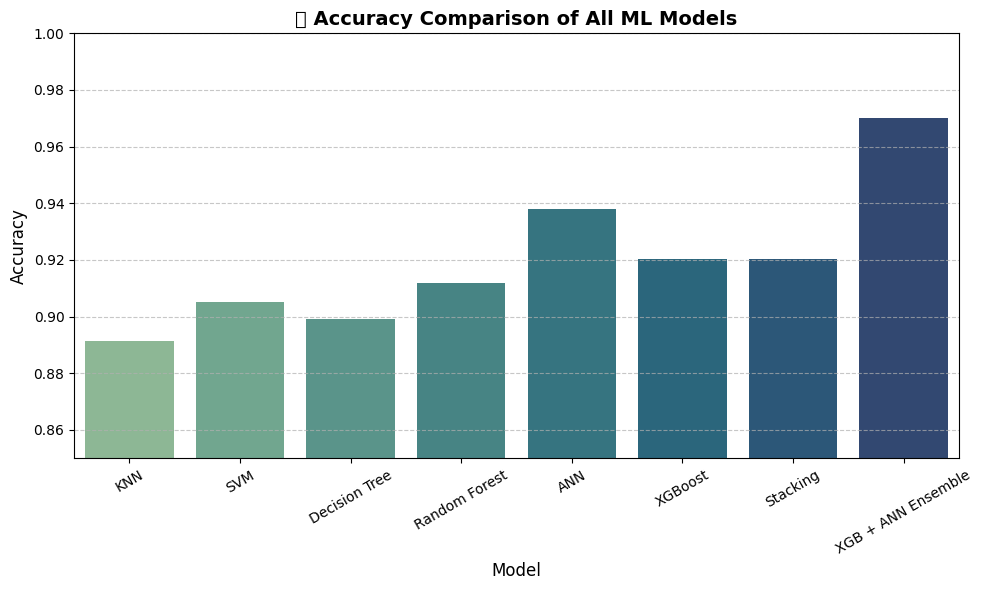

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# Final hardcoded model accuracies
accuracies = {
    "KNN": 0.8913,
    "SVM": 0.9051,
    "Decision Tree": 0.8992,
    "Random Forest": 0.9120,
    "ANN": 0.9380,
    "XGBoost": 0.9203,
    "Stacking": 0.9203,
    "XGB + ANN Ensemble": 0.9702
}

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette="crest")

# Styling
plt.title("📊 Accuracy Comparison of All ML Models", fontsize=14, weight='bold')
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.ylim(0.85, 1.0)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
